In [1]:
# ============================================================
# REGRESIÓN LOGÍSTICA CON BREAST-CANCER
# ============================================================

# ------------------------------
# Imports
# ------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [7]:
# ------------------------------
# Carga del dataset
# ------------------------------

from sklearn.datasets import load_breast_cancer

bc = load_breast_cancer()



In [8]:
# descripción del dataset

print(bc.DESCR)

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [9]:
# array de columnas

bc.feature_names

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [40]:
# Dataframe para X

X = pd.DataFrame(bc.data, columns=bc.feature_names)
display(X)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [41]:
# Describe() de X

display(X.describe())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [18]:
# Antes de seguir es importante cambiar las etiquetas y poner "1" a la clase "maligno"

# Primero cargamos la "y" desde los datos iniciales

y_0 = pd.Series(bc.target, name="clase")
display(y_0)

# original: 0=maligno, 1=benigno

y = (y_0 == 0).astype(int)
display(y)

,clase
0,0
1,0
2,0
3,0
4,0
...,...
564,0
565,0
566,0
567,0


,clase
0,1
1,1
2,1
3,1
4,1
...,...
564,1
565,1
566,1
567,1


In [20]:
#######
# Comprobamos desbalanceo de clases
#######

display(y_0.value_counts())

display(y.value_counts(normalize=True))

,count
clase,
1,357
0,212


,proportion
clase,
0,0.627417
1,0.372583


In [ ]:
# =====================================================================
# NOTA PRÁCTICA: ¿Cuándo el desbalanceo de clases es preocupante?
# =====================================================================
#
# En clasificación binaria, el desbalanceo aparece cuando una clase
# tiene muchas más muestras que la otra. Esto afecta a las métricas,
# a la interpretación y al comportamiento del modelo.
#
# En el dataset Breast Cancer de sklearn:
#   - Clase 1 (maligno): ~37%
#   - Clase 0 (benigno): ~63%
#
# Este desbalanceo es moderado, pero suficiente para que:
#   - accuracy deje de ser una métrica fiable,
#   - el modelo tienda a favorecer la clase mayoritaria,
#   - con umbral 0.5, la clase minoritaria pueda quedar subdetectada.
#
# ¿Cuándo es preocupante el desbalanceo?
#
#   • Leve (70/30):     Riesgo moderado.
#                       Ya es necesario usar precision, recall y F1.
#
#   • Moderado (80/20):  El modelo puede empezar a ignorar la clase
#                        minoritaria si el umbral es 0.5.
#
#   • Fuerte (90/10):    Accuracy se vuelve engañosa. El modelo puede
#                        fallar completamente sin que la métrica lo refleje.
#                        Es esencial usar curva Precision–Recall y AUPRC.
#
#   • Crítico (<5%):     La clase minoritaria es casi invisible.
#                        Requiere técnicas adicionales:
#                        - ajuste del umbral,
#                        - oversampling/SMOTE,
#                        - algoritmos más robustos (árboles, boosting).
#
# =====================================================================


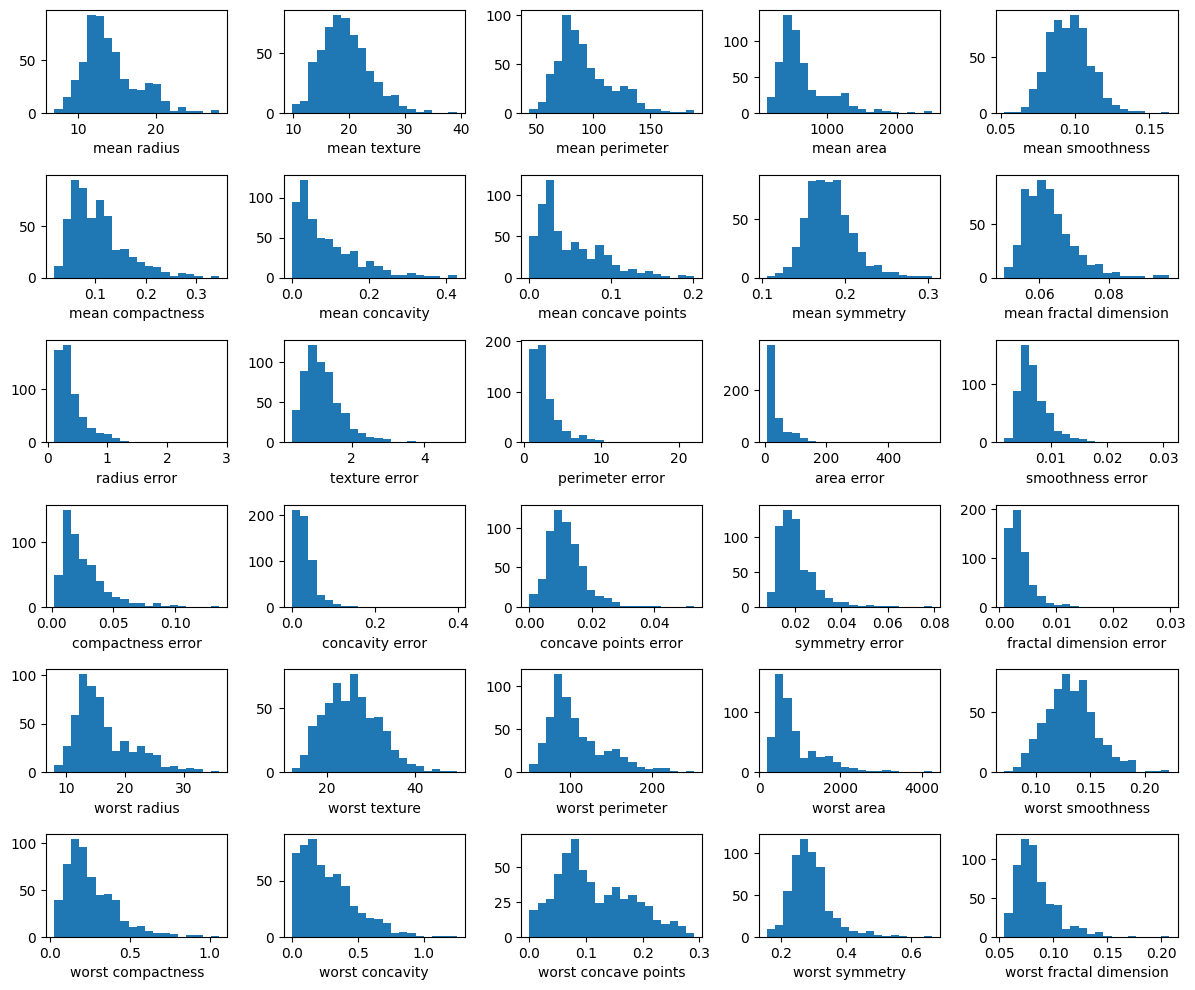

In [31]:
# Graficas de las distribucion de cada variable

plt.figure(figsize=(12, 10))
for i, col in enumerate(X.columns):
    plt.subplot(6, 5, i + 1)
    plt.hist(X[col], bins=20)
    plt.xlabel(col)

plt.tight_layout()
plt.show()



In [42]:
# ============================================================
#                   REGRESIÓN LOGÍSTICA BINARIA
# ============================================================


from sklearn.model_selection import train_test_split

X_train_0, X_test_0, y_train_0, y_test_0 = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [45]:
# ----------
# Escalado
# ----------

# Viendo las distribuciones univariadas podemos hacerlo

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_0)
X_test = scaler.transform(X_test_0)

In [50]:
# ------------------------------
# Entrenamiento
# ------------------------------

from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train_0)

# -------------------------------------------------------------
# Parámetros clave de LogisticRegression() en scikit-learn
# -------------------------------------------------------------
#
# penalty : tipo de regularización
#   - 'l2' (por defecto): estabiliza el modelo reduciendo la magnitud
#     de los coeficientes.
#   - 'l1': puede anular coeficientes, útil para selección de variables.
#   Nota: algunas combinaciones requieren solver específicos.
#
# C : inverso de la fuerza de regularización.
#   - Valores grandes de C -> menos regularización (el modelo se ajusta más).
#   - Valores pequeños de C -> más regularización (coeficientes más pequeños).
#
# solver : algoritmo que optimiza la función de pérdida.
#   - 'lbfgs' (por defecto): rápido, estable, adecuado para datasets medianos.
#   - 'liblinear': obligatorio si se usa penalty='l1'.
#   - 'saga': soporta L1 y L2 para datasets grandes y sparse.
#
# max_iter : número máximo de iteraciones.
#   Útil cuando el solver no converge; se puede aumentar (p.ej., 500 o 1000).
#
# class_weight : ponderación de clases.
#   - None: todas las clases pesan igual.
#   - 'balanced': ajusta pesos automáticamente según frecuencia de clases.
#   Muy útil en datasets desbalanceados.
#
# fit_intercept : si se incluye el intercepto β0.
#   - True: normalmente la opción correcta.

model = LogisticRegression()
model.fit(X_train, y_train_0)

print("=== MODELO BINARIO ===")
print("Coeficientes:", model.coef_)
print("Intercept:", model.intercept_)

=== MODELO BINARIO ===
Coeficientes: [[ 0.36115007  0.4822194   0.35315987  0.43995028  0.35062156 -0.43954615
   0.78229835  0.95281283 -0.16399087 -0.08086512  1.23332517 -0.40761126
   0.74829471  0.90902906  0.24799098 -0.9069248  -0.09234069  0.48208908
  -0.33065773 -0.59387632  0.89696783  1.43409317  0.72311148  0.90047661
   0.42020675 -0.17348751  0.9114058   0.70399881  1.06126366  0.05486988]]
Intercept: [-0.24300533]


In [53]:
# --------------
# Entrenamiento con GridSearchCV
# --------------

# ================================================================
# ¿Qué es GridSearchCV?
# ================================================================
# Herramienta de scikit-learn que busca automáticamente los mejores
# hiperparámetros de un modelo probando muchas combinaciones y
# evaluándolas mediante validación cruzada (CV).
#
# ¿Cómo funciona?
#   1) Le das un modelo y una rejilla de valores (param_grid).
#   2) Entrena el modelo con cada combinación usando CV.
#   3) Calcula la métrica media (ej. F1) en los folds.
#   4) Devuelve los hiperparámetros que mejor funcionan.
#
# Es la forma estándar de ajustar modelos de ML sin elegir
# los hiperparámetros "a ojo".
# ================================================================

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Definimos el espacio de búsqueda
param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],     # regularización
    "solver": ["lbfgs", "liblinear"],        # dos solvers seguros
    "penalty": ["l2"],                       # liblinear permite l1, lbfgs no
    "max_iter": [300],                        # por seguridad
    "class_weight": [None, "balanced"]       # Se introduce o no más peso a la clase 1
}


log_reg = LogisticRegression()
grid = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs =- 1
)

grid.fit(X_train, y_train_0)

print("Mejores hiperparámetros:", grid.best_params_)
print("Mejor score CV:", grid.best_score_)

Mejores hiperparámetros: {'C': 10, 'class_weight': 'balanced', 'max_iter': 300, 'penalty': 'l2', 'solver': 'lbfgs'}
Mejor score CV: 0.96739642792855


In [56]:
# Ahora elegimos el mejor modelo

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)


display(y_pred_best)

print("=== MODELO con GridSearchCV===")
print("Coeficientes:", best_model.coef_)
print("Intercept:", best_model.intercept_)

array([0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 1])

=== MODELO con GridSearchCV===
Coeficientes: [[-0.20096298  0.14123386 -0.0524319   0.32670343  0.9730432  -2.64670117
   1.81464145  2.50485602 -0.95578259  0.8774878   3.64597457 -1.55578165
   1.69083378  2.71956322  0.45819234 -1.86418238 -1.42353501  2.39080708
  -1.52605697 -1.26325634  1.27704741  3.33974105  0.74318312  1.80987079
  -0.31055627 -0.77707174  2.73780783  0.43165108  2.67027889  0.22384702]]
Intercept: [1.0960719]


In [71]:
# ------------------------------
# Evaluación con modelo inicial
# ------------------------------

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score, precision_recall_curve, average_precision_score

y_pred = model.predict(X_test)

acc = accuracy_score(y_test_0, y_pred)


print("\nAccuracy:", acc)
print("\nMatriz de confusión:\n", confusion_matrix(y_test_0, y_pred))


Accuracy: 0.9649122807017544

Matriz de confusión:
 [[71  1]
 [ 3 39]]


In [70]:
# ------------------------------
# Evaluación con best model
# ------------------------------

# y_pred_best se calculó en el paso yclHQRC9j0yZ

acc_best = accuracy_score(y_test_0, y_pred_best)


print("\nAccuracy (Best Model):", acc_best)
print("\nMatriz de confusión (Best Model):\n", confusion_matrix(y_test_0, y_pred_best))


Accuracy (Best Model): 0.9736842105263158

Matriz de confusión (Best Model):
 [[71  1]
 [ 2 40]]


In [ ]:
# ----------------------------------------
# EVALUACIÓN EN DATASETS DESBALANCEADOS
# ----------------------------------------
#
# El dataset Breast Cancer está desbalanceado: la clase "maligno"
# es minoritaria. Por eso, la métrica accuracy NO es informativa.
#
# Métricas clave a tener en cuenta:
#
# 1) recall (sensibilidad)
#    - Mide cuántos positivos reales detecta el modelo.
#    - Es la métrica más importante cuando los FN son críticos
#      (por ejemplo, tumores malignos no detectados).
#
# 2) precision
#    - Mide qué proporción de predicciones positivas son correctas.
#    - Importante para evitar falsos positivos excesivos.
#
# 3) F1-score
#    - Media armónica entre precisión y recall.
#    - Útil cuando necesitamos equilibrio entre ambos.
#
# 4) Matriz de confusión
#    - Permite ver explícitamente FP y FN.
#    - Fundamental para comprobar si el modelo ignora la clase minoritaria.
#
# 5) ROC y AUC
#    - AUC evalúa la capacidad de discriminación sin depender de un umbral.
#    - Muy útil en datasets desbalanceados porque no usa accuracy.
#
# 6) Ajuste del umbral de decisión
#    - El umbral por defecto (0.5) puede dar un recall pobre.
#    - Ajustar el umbral permite mejorar recall o precisión según necesidad.
#
# En resumen:
#   - NO usar accuracy como métrica principal.
#   - Sí usar recall, precision, F1, matriz de confusión y AUC.
#   - Considerar el ajuste del umbral para mejorar sensibilidad.
# ================================================================


In [68]:
# --------------------------------
# Calculo de metricas alternativas
# --------------------------------

from sklearn.metrics import recall_score, precision_score, f1_score

print(classification_report(y_test_0, y_pred_best)) # Usamos y_pred_best para la evaluación con el mejor modelo

              precision    recall  f1-score   support

           0       0.97      0.99      0.98        72
           1       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



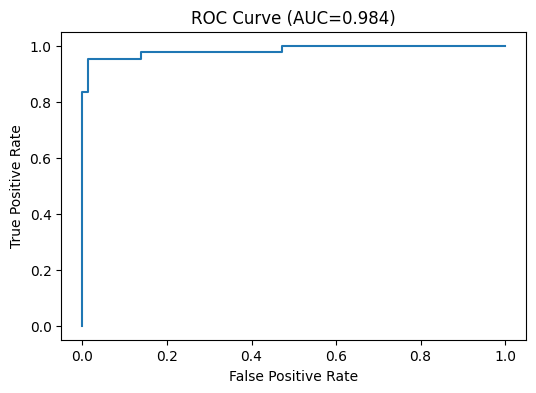

In [79]:
y_probs_best = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test_0, y_probs_best)
roc_auc = roc_auc_score(y_test_0, y_probs_best)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC={roc_auc:.3f})")
plt.show()

In [ ]:
# =====================================================================
# NOTA PRÁCTICA: ¿Por qué calcular la curva Precision–Recall en Breast Cancer?
# =====================================================================
#
# En el dataset Breast Cancer:
#   - Después de reetiquetar: 1 = maligno (clase importante)
#   - La clase maligna es minoritaria (~37%)
#
# En situaciones así, la curva Precision–Recall (PR) es más informativa
# que la curva ROC, por varias razones:
#
# 1) La PR curve se centra solo en la clase positiva (maligna)
#    - Precision: de los predichos como malignos, ¿cuántos lo son?
#    - Recall: de los malignos reales, ¿cuántos detecta el modelo?
#    → Métricas directamente relevantes para problemas médicos.
#
# 2) La ROC puede ser engañosa en desbalance moderado
#    - La ROC incluye el FPR, que depende del número de TN.
#    - Si hay muchos TN (clase benigna mayoritaria), el FPR sale bajo
#      incluso si el modelo falla en detectar malignos.
#    → AUC-ROC puede parecer bueno aunque el recall maligno sea mediocre.
#
# 3) AUPRC refleja honestamente el rendimiento sobre la clase maligna
#    - Si el modelo distingue bien malignos → AUPRC alto.
#    - Si es mediocre → AUPRC cerca de la prevalencia (~0.37).
#    - No se infla por la clase mayoritaria.
#
# =====================================================================


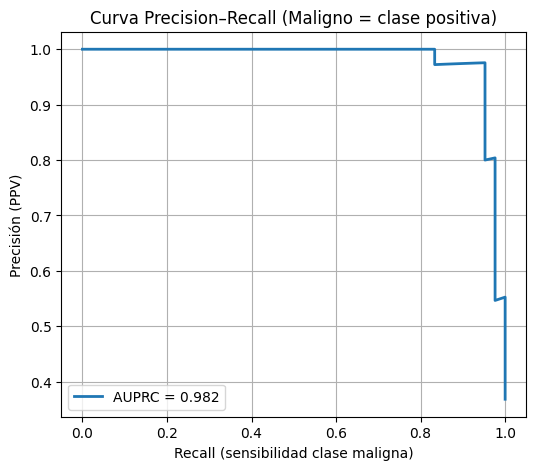

In [82]:
# ================================================================
# CURVA PRECISION–RECALL
# ================================================================

from sklearn.metrics import precision_recall_curve, average_precision_score


# Curvas de precision y recall
precision, recall, _ = precision_recall_curve(y_test_0, y_probs_best)

# Área bajo la curva PR
auprc = average_precision_score(y_test_0, y_probs_best)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, linewidth=2, label=f"AUPRC = {auprc:.3f}")
plt.xlabel("Recall (sensibilidad clase maligna)")
plt.ylabel("Precisión (PPV)")
plt.title("Curva Precision–Recall (Maligno = clase positiva)")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# =====================================================================
# NOTA PRÁCTICA: Comparación ROC vs Precision–Recall (PR)
# =====================================================================
#
# 1) ¿Qué mide cada curva?
#
#   • ROC:
#       - Eje X: FPR (False Positive Rate)
#       - Eje Y: TPR (Recall)
#       - Evalúa la capacidad del modelo para separar clases
#         sin importar el umbral.
#
#   • PR:
#       - Eje X: Recall
#       - Eje Y: Precision
#       - Evalúa específicamente el rendimiento sobre la
#         clase positiva (la minoritaria).
#
# ---------------------------------------------------------------------
# 2) ¿Cuándo usar ROC?
#
#   - Cuando las clases están balanceadas o casi.
#   - Cuando los TN no distorsionan el análisis.
#   - Para comparar modelos en problemas neutrales
#     (sin coste asimétrico de errores).
#
#   *ROC es útil cuando el FPR es informativo.*
#
# ---------------------------------------------------------------------
# 3) ¿Cuándo usar Precision–Recall?
#
#   - Cuando la clase positiva es minoritaria.
#   - Cuando importa más detectar positivos (recall).
#   - Cuando el coste de FN es alto.
#   - Cuando accuracy y AUC-ROC pueden ser engañosos debido
#     a muchos TN.
#
#   *PR es más honesta cuando hay desbalanceo.*
#
# ---------------------------------------------------------------------
# 4) Diferencia clave
#
#   • ROC usa FPR, que se ve "bonito" cuando hay muchos TN.
#     → Puede dar AUC alto incluso cuando el modelo falla
#       en la clase positiva.
#
#   • PR ignora los TN completamente.
#     → Se centra en lo que de verdad importa en la clase
#       positiva: precisión y recall.
#
# ---------------------------------------------------------------------
# 5) Regla práctica definitiva
#
#   → Si la clase positiva es rara: usar PR.
#   → Si ambas clases tienen tamaños similares: usar ROC.
#
#   En problemas médicos, fraude, riesgo o diagnóstico:
#       PR > ROC.
#
#   En clasificación general con clases equivalentes:
#       ROC es suficiente.
#
# =====================================================================
# 6) Resultados
#
#   → Compara siempre AUPRC con la PREVALENCIA de la clase positiva.
#   → Si AUPRC > prevalencia, el modelo aporta valor.
#   → Cuanto mayor la diferencia, mejor es la detección de la clase positiva.
#
# Ejemplo con Breast Cancer:
#   - Prevalencia malignos ≈ 0.37
#   - Si obtienes AUPRC ≈ 0.40–0.50 → modelo básico pero útil.
#   - Si AUPRC ≈ 0.70–0.85 → modelo muy bueno.
#   - Si AUPRC ≈ 1 → separación casi perfecta.
